In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

In [2]:
chapter = 'K1'

In [33]:
savefolder = f'../img/{chapter}/'

In [4]:
# ============================================================
# Standard-Einstellungen
# ============================================================
from matplotlib.transforms import blended_transform_factory

DEFAULT_COLORS = {
    "primary": "#1f77b4",      # Hauptfarbe
    "secondary": "#ff7f0e",    # Zweitfarbe
    "accent": "#2ca02c",       # Akzentfarbe
    "grid": "#d0d0d0",
    "axes": "black"
}


def setup_plot(
    figsize=(6, 4),
    show_ticks=False,
    xlabel="x",
    ylabel="y",
    xlim=None,
    ylim=None,
    grid=False,
    colors=None
):
    """
    Erstellt ein Koordinatensystem mit Achsen durch den Ursprung.

    Parameters
    ----------
    show_ticks : bool
        Achsenbeschriftungen anzeigen?
    """

    if colors is None:
        colors = DEFAULT_COLORS

    fig, ax = plt.subplots(figsize=figsize)

    # Achsen durch den Ursprung
    ax.spines["top"].set_color("none")
    ax.spines["right"].set_color("none")

    ax.spines["bottom"].set_position("zero")
    ax.spines["left"].set_position("zero")

    ax.spines["bottom"].set_color(colors["axes"])
    ax.spines["left"].set_color(colors["axes"])

    # # Achsenbeschriftungen
    # ax.set_xlabel(xlabel)
    # ax.set_ylabel(ylabel)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()


    # Tickmarks
    if not show_ticks:
        ax.set_xticks([])
        ax.set_yticks([])

    # Grenzen
    if xlim is not None:
        ax.set_xlim(*xlim)

    if ylim is not None:
        ax.set_ylim(*ylim)

    # Achsenbeschriftungen
    trans_x = blended_transform_factory(ax.transAxes, ax.transData)
    trans_y = blended_transform_factory(ax.transData, ax.transAxes)

    ax.text(
        1.02,      # etwas rechts vom Plot
        0,         # y = 0
        xlabel,
        transform=trans_x,
        ha="left",
        va="center"
    )

    ax.text(
        0,         # x = 0
        1.02,      # etwas oberhalb des Plots
        ylabel,
        transform=trans_y,
        ha="center",
        va="bottom"
    )

    # Gitter
    if grid:
        ax.grid(
            True,
            color=colors["grid"],
            linestyle="--",
            alpha=0.35
        )

    return fig, ax

In [5]:
def quadratic_func(x):
    return x**2

def cubic_func(x):
    return x**3

def linear_func(x):
    return x

In [6]:
# x_space = np.linspace(-1,1,100)

# fig, ax = setup_plot(
#     show_ticks=True,
#     xlim=(-1, 1),
#     ylim=(-1, 1),
#     grid=True
# )

# plt.plot(
#     x_space,
#     linear_func(x_space),
#     label='$f_n = x^1$'
# )

# plt.plot(
#     x_space,
#     quadratic_func(x_space),
#     label='$f_n = x^2$'
# )

# plt.plot(
#     x_space,
#     cubic_func(x_space),
#     label='$f_n = x^3$'
# )

# plt.legend()
# plt.savefig(f'{savefolder}Beispiel_L2_Konvergenz.pdf')
# plt.show()

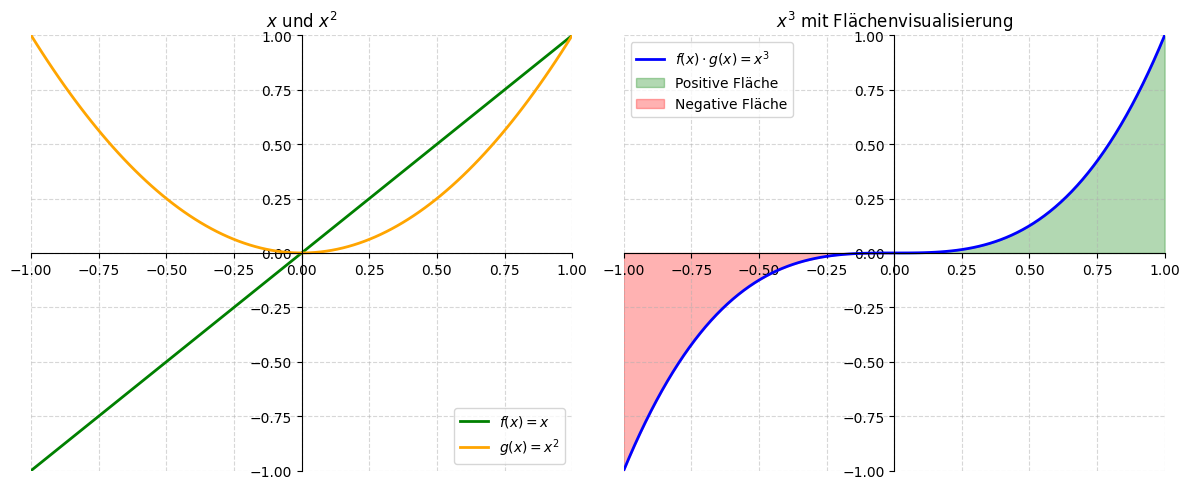

In [7]:
x_space = np.linspace(-1, 1, 100)

# Erstelle Figure mit zwei Subplots nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === Funktionen für Achsenkreuz setzen ===
def set_axes_cross(ax):
    """Verschiebt die Achsen zum Ursprung und blendet Rahmen aus"""
    ax.spines['bottom'].set_position('center')  # x-Achse bei y=0
    ax.spines['left'].set_position('center')    # y-Achse bei x=0
    
    # Rechte und obere Achse verstecken
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    
    # Pfeilspitzen für die Achsen hinzufügen (optional)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    # Gitterlinien beibehalten
    ax.grid(True, linestyle='--', alpha=0.5)


# === Linker Plot: x^1 und x^2 ===
ax_left = axes[0]
set_axes_cross(ax_left)

ax_left.set_xlim(-1, 1)
ax_left.set_ylim(-1, 1)

ax_left.plot(
    x_space,
    linear_func(x_space),
    label='$f(x) = x$',
    color='green',
    linewidth=2
)

ax_left.plot(
    x_space,
    quadratic_func(x_space),
    label='$g(x) = x^2$',
    color='orange',
    linewidth=2
)

ax_left.legend(loc='lower right')
ax_left.set_title('$x$ und $x^2$')


# === Rechter Plot: x^3 mit Fläche ===
ax_right = axes[1]
set_axes_cross(ax_right)

ax_right.set_xlim(-1, 1)
ax_right.set_ylim(-1, 1)

ax_right.plot(
    x_space,
    cubic_func(x_space),
    label=r'$f(x) \cdot g(x) = x^3$',
    color='blue',
    linewidth=2
)


# Nur über der x-Achse
ax_right.fill_between(x_space, cubic_func(x_space), 0, where=cubic_func(x_space) >= 0, 
                      alpha=0.3, color='green', label='Positive Fläche')

# Unter der x-Achse separat
ax_right.fill_between(x_space, cubic_func(x_space), 0, where=cubic_func(x_space) < 0, 
                      alpha=0.3, color='red', label='Negative Fläche')

ax_right.legend(loc='upper left')
ax_right.set_title('$x^3$ mit Flächenvisualisierung')


# Gesamte Figur speichern und anzeigen
plt.tight_layout()
plt.savefig(f'{savefolder}Orthogonale_Funktionen.pdf')
plt.show()

In [8]:
def c_k(k, x):
    return np.cos(k * x)

def s_l(l, x):
    return np.sin(l * x)

In [9]:
# x_space = np.linspace(0, 2 * np.pi, 100)

# # Erstelle Figure mit 2 Zeilen, 3 Spalten
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# # === Zeile 1: Cos-Sin Kombinationen ===

# # Fall 1: Cos-Sin | l ≠ k
# ax1 = axes[0, 0]
# set_axes_cross(ax1)
# ax1.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
# ax1.plot(x_space, s_l(2, x_space), color='orange', linewidth=2, label='$sin(2x)$')
# ax1.set_xlim(-0.5, 2*np.pi + 0.5)
# ax1.set_ylim(-1.5, 1.5)
# ax1.axhline(y=0, color='black', linewidth=0.8)
# ax1.axvline(x=np.pi, color='gray', linestyle=':', alpha=0.5)  # Orientierungshilfe
# ax1.legend(loc='upper right')
# ax1.set_title(r'$\cos(kx), \sin(lx)$ | $l \neq k$')
# ax1.text(np.pi, -1.3, r'$k=1, l=2$', ha='center')

# # Fall 2: Cos-Sin | l = k ≠ 0
# ax2 = axes[0, 1]
# set_axes_cross(ax2)
# ax2.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
# ax2.plot(x_space, s_l(1, x_space), color='orange', linewidth=2, label='$sin(x)$')
# ax2.set_xlim(-0.5, 2*np.pi + 0.5)
# ax2.set_ylim(-1.5, 1.5)
# ax2.axhline(y=0, color='black', linewidth=0.8)
# ax2.legend(loc='upper right')
# ax2.set_title(r'$\cos(kx), \sin(lx)$ | $l = k \neq 0$')
# ax2.text(np.pi, -1.3, r'$k=l=1$', ha='center')

# # Fall 3: Cos-Sin | l = k = 0
# ax3 = axes[0, 2]
# set_axes_cross(ax3)
# ax3.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
# ax3.plot(x_space, s_l(0, x_space), color='orange', linewidth=2, label=r'$sin(0x) = 0$')
# ax3.axhline(y=1, color='blue', linestyle='--', alpha=0.5)
# ax3.axhline(y=0, color='orange', linestyle='-', linewidth=2)
# ax3.set_xlim(-0.5, 2*np.pi + 0.5)
# ax3.set_ylim(-1.5, 1.5)
# ax3.axhline(y=0, color='black', linewidth=0.8)
# ax3.legend(loc='lower right')
# ax3.set_title(r'$\cos(kx), \sin(lx)$ | $l = k = 0$')
# ax3.text(np.pi, -1.3, r'$k=l=0$', ha='center')


# # === Zeile 2: Cos-Cos Kombinationen ===

# # Fall 4: Cos-Cos | l ≠ k
# ax4 = axes[1, 0]
# set_axes_cross(ax4)
# ax4.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
# ax4.plot(x_space, c_k(2, x_space), color='green', linewidth=2, label=r'$cos(2x)$')
# ax4.set_xlim(-0.5, 2*np.pi + 0.5)
# ax4.set_ylim(-1.5, 1.5)
# ax4.axhline(y=0, color='black', linewidth=0.8)
# ax4.legend(loc='upper right')
# ax4.set_title(r'$\cos(kx), \cos(lx)$ | $l \neq k$')
# ax4.text(np.pi, -1.3, r'$k=1, l=2$', ha='center')

# # Fall 5: Cos-Cos | l = k ≠ 0
# ax5 = axes[1, 1]
# set_axes_cross(ax5)
# ax5.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
# ax5.plot(x_space, c_k(1, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(x)$ (identisch)')
# ax5.set_xlim(-0.5, 2*np.pi + 0.5)
# ax5.set_ylim(-1.5, 1.5)
# ax5.axhline(y=0, color='black', linewidth=0.8)
# ax5.legend(loc='upper right')
# ax5.set_title(r'$\cos(kx), \cos(lx)$ | $l = k \neq 0$')
# ax5.text(np.pi, -1.3, r'$k=l=1$', ha='center')

# # Fall 6: Cos-Cos | l = k = 0
# ax6 = axes[1, 2]
# set_axes_cross(ax6)
# ax6.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
# ax6.plot(x_space, c_k(0, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(0x) = 1$ (identisch)')
# ax6.set_xlim(-0.5, 2*np.pi + 0.5)
# ax6.set_ylim(-1.5, 1.5)
# ax6.axhline(y=0, color='black', linewidth=0.8)
# ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
# ax6.legend(loc='lower right')
# ax6.set_title(r'$\cos(kx), \cos(lx)$ | $l = k = 0$')
# ax6.text(np.pi, -1.3, r'$k=l=0$', ha='center')


# plt.suptitle('Fourier-Basis-Funktionen: Orthogonalitätsfälle', fontsize=16, fontweight='bold')
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # Platz für Titel lassen

# # Speichern und anzeigen
# plt.savefig(f'{savefolder}Fourier_Basis_Funktionen.pdf')
# plt.show()

In [10]:
# x_space = np.linspace(0, 2 * np.pi, 100)

# # Erstelle Figure mit 2 Zeilen, 3 Spalten
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))


# # === Zeile 1: Cos × Sin Produkte ===

# # Fall 1: Cos×Sin | l ≠ k
# ax1 = axes[0, 0]
# set_axes_cross(ax1)
# product_1 = c_k(1, x_space) * s_l(2, x_space)
# ax1.plot(x_space, product_1, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(2x)$')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 >= 0, alpha=0.4, color='green', label='Positive Fläche')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 < 0, alpha=0.4, color='red', label='Negative Fläche')
# ax1.set_xlim(-0.5, 2*np.pi + 0.5)
# ax1.set_ylim(-1.5, 1.5)
# ax1.axhline(y=0, color='black', linewidth=0.8)
# ax1.legend(loc='upper right')
# ax1.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l \neq k$')
# integral_value_1 = np.trapezoid(product_1, x_space)
# ax1.text(np.pi, -1.3, f'$k=1, l=2$, ∫≈{integral_value_1:.4f}', ha='center')

# # Fall 2: Cos×Sin | l = k ≠ 0
# ax2 = axes[0, 1]
# set_axes_cross(ax2)
# product_2 = c_k(1, x_space) * s_l(1, x_space)
# ax2.plot(x_space, product_2, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(x)$')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 >= 0, alpha=0.4, color='green', label='Positive Fläche')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 < 0, alpha=0.4, color='red', label='Negative Fläche')
# ax2.set_xlim(-0.5, 2*np.pi + 0.5)
# ax2.set_ylim(-1.5, 1.5)
# ax2.axhline(y=0, color='black', linewidth=0.8)
# ax2.legend(loc='upper right')
# ax2.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k \neq 0$')
# integral_value_2 = np.trapezoid(product_2, x_space)
# ax2.text(np.pi, -1.3, f'$k=l=1$, ∫≈{integral_value_2:.4f}', ha='center')

# # Fall 3: Cos×Sin | l = k = 0
# ax3 = axes[0, 2]
# set_axes_cross(ax3)
# product_3 = c_k(0, x_space) * s_l(0, x_space)  # = 1 × 0 = 0
# ax3.plot(x_space, product_3, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \sin(0x) = 0$')
# ax3.fill_between(x_space, product_3, 0, alpha=0.4, color='gray', label='Fläche = 0')
# ax3.set_xlim(-0.5, 2*np.pi + 0.5)
# ax3.set_ylim(-1.5, 1.5)
# ax3.axhline(y=0, color='black', linewidth=0.8)
# ax3.axhline(y=0, color='orange', linestyle='-', linewidth=3)  # Highlight x-Achse
# ax3.legend(loc='upper right')
# ax3.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k = 0$')
# integral_value_3 = np.trapezoid(product_3, x_space)
# ax3.text(np.pi, -1.3, f'$k=l=0$, ∫={integral_value_3}', ha='center')


# # === Zeile 2: Cos × Cos Produkte ===

# # Fall 4: Cos×Cos | l ≠ k
# ax4 = axes[1, 0]
# set_axes_cross(ax4)
# product_4 = c_k(1, x_space) * c_k(2, x_space)
# ax4.plot(x_space, product_4, color='purple', linewidth=2, label=r'$\cos(x) \cdot \cos(2x)$')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 >= 0, alpha=0.4, color='green', label='Positive Fläche')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 < 0, alpha=0.4, color='red', label='Negative Fläche')
# ax4.set_xlim(-0.5, 2*np.pi + 0.5)
# ax4.set_ylim(-1.5, 1.5)
# ax4.axhline(y=0, color='black', linewidth=0.8)
# ax4.legend(loc='upper right')
# ax4.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l \neq k$')
# integral_value_4 = np.trapezoid(product_4, x_space)
# ax4.text(np.pi, -1.3, f'$k=1, l=2$, ∫≈{integral_value_4:.4f}', ha='center')

# # Fall 5: Cos×Cos | l = k ≠ 0
# ax5 = axes[1, 1]
# set_axes_cross(ax5)
# product_5 = c_k(1, x_space) * c_k(1, x_space)  # = cos²(x)
# ax5.plot(x_space, product_5, color='purple', linewidth=2, label=r'$\cos^2(x)$')
# ax5.fill_between(x_space, product_5, 0, alpha=0.4, color='blue', label='Fläche über x-Achse')
# ax5.set_xlim(-0.5, 2*np.pi + 0.5)
# ax5.set_ylim(-1.5, 1.5)
# ax5.axhline(y=0, color='black', linewidth=0.8)
# # ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)  # Mittelwert y=0.5
# ax5.legend(loc='upper right')
# ax5.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k \neq 0$')
# integral_value_5 = np.trapezoid(product_5, x_space)
# ax5.text(np.pi, -1.3, f'$k=l=1$, ∫≈{integral_value_5:.4f}', ha='center')

# # Fall 6: Cos×Cos | l = k = 0
# ax6 = axes[1, 2]
# set_axes_cross(ax6)
# product_6 = c_k(0, x_space) * c_k(0, x_space)  # = 1 × 1 = 1
# ax6.plot(x_space, product_6, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \cos(0x) = 1$')
# ax6.fill_between(x_space, product_6, 0, alpha=0.4, color='blue', label='Fläche = Rectangle')
# ax6.set_xlim(-0.5, 2*np.pi + 0.5)
# ax6.set_ylim(-1.5, 1.5)
# ax6.axhline(y=0, color='black', linewidth=0.8)
# # ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Niveau y=1
# ax6.legend(loc='upper right')
# ax6.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k = 0$')
# integral_value_6 = np.trapezoid(product_6, x_space)
# ax6.text(np.pi, -1.3, f'$k=l=0$, ∫≈{integral_value_6:.4f}', ha='center')


# plt.suptitle('Orthogonalität von Fourier-Basis-Funktionen: Produkte & Integrale', fontsize=16, fontweight='bold')
# plt.tight_layout(rect=[0, 0, 1, 0.95])

# # Speichern und anzeigen
# plt.savefig(f'{savefolder}Fourier_Produkte_Flaechen.pdf')
# plt.show()

In [11]:
# x_space = np.linspace(0, 2 * np.pi, 100)

# # Erstelle Figure mit 4 Zeilen, 3 Spalten
# fig, axes = plt.subplots(4, 3, figsize=(15, 12))

# # === Zeile 1: Cos × Sin Produkte ===

# # Fall 1: Cos×Sin | l ≠ k
# ax1 = axes[0, 0]
# set_axes_cross(ax1)
# product_1 = c_k(1, x_space) * s_l(2, x_space)
# ax1.plot(x_space, product_1, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(2x)$')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 >= 0, alpha=0.4, color='green')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 < 0, alpha=0.4, color='red')
# ax1.set_ylim(-1.5, 1.5)
# ax1.legend(loc='upper right', fontsize=8)
# ax1.set_title(r'$\cos(kx)\sin(lx)$, $l \neq k$', fontsize=10)
# integral_value_1 = np.trapezoid(product_1, x_space)
# ax1.text(np.pi, -1.35, f'∫≈{integral_value_1:.4f}', ha='center', fontsize=8)

# # Fall 2: Cos×Sin | l = k ≠ 0
# ax2 = axes[0, 1]
# set_axes_cross(ax2)
# product_2 = c_k(2, x_space) * s_l(2, x_space)
# ax2.plot(x_space, product_2, color='purple', linewidth=2, label=r'$\cos(2x) \cdot \sin(2x)$')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 >= 0, alpha=0.4, color='green')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 < 0, alpha=0.4, color='red')
# ax2.set_ylim(-1.5, 1.5)
# ax2.legend(loc='upper right', fontsize=8)
# ax2.set_title(r'$\cos(kx)\sin(lx)$, $l = k \neq 0$', fontsize=10)
# integral_value_2 = np.trapezoid(product_2, x_space)
# ax2.text(np.pi, -1.35, f'∫≈{integral_value_2:.4f}', ha='center', fontsize=8)

# # Fall 3: Cos×Sin | l = k = 0
# ax3 = axes[0, 2]
# set_axes_cross(ax3)
# product_3 = c_k(0, x_space) * s_l(0, x_space)
# ax3.plot(x_space, product_3, color='purple', linewidth=2, label=r'$\cos(0)\cdot\sin(0) = 0$')
# ax3.fill_between(x_space, product_3, 0, alpha=0.4, color='gray')
# ax3.set_ylim(-1.5, 1.5)
# ax3.legend(loc='lower left', fontsize=8)
# ax3.set_title(r'$\cos(kx)\sin(lx)$, $l = k = 0$', fontsize=10)
# integral_value_3 = np.trapezoid(product_3, x_space)
# ax3.text(np.pi, -1.35, f'∫={integral_value_3}', ha='center', fontsize=8)


# # === Zeile 2: Cos × Cos Produkte ===

# # Fall 4: Cos×Cos | l ≠ k
# ax4 = axes[1, 0]
# set_axes_cross(ax4)
# product_4 = c_k(1, x_space) * c_k(2, x_space)
# ax4.plot(x_space, product_4, color='blue', linewidth=2, label=r'$\cos(x) \cdot \cos(2x)$')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 >= 0, alpha=0.4, color='green')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 < 0, alpha=0.4, color='red')
# ax4.set_ylim(-1.5, 1.5)
# ax4.legend(loc='upper right', fontsize=8)
# ax4.set_title(r'$\cos(kx)\cos(lx)$, $l \neq k$', fontsize=10)
# integral_value_4 = np.trapezoid(product_4, x_space)
# ax4.text(np.pi, -1.35, f'∫≈{integral_value_4:.4f}', ha='center', fontsize=8)

# # Fall 5: Cos×Cos | l = k ≠ 0
# ax5 = axes[1, 1]
# set_axes_cross(ax5)
# product_5 = c_k(1, x_space) * c_k(1, x_space)
# ax5.plot(x_space, product_5, color='blue', linewidth=2, label=r'$\cos^2(x)$')
# ax5.fill_between(x_space, product_5, 0, alpha=0.4, color='lightblue')
# ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax5.set_ylim(-0.2, 1.2)
# ax5.legend(loc='upper right', fontsize=8)
# ax5.set_title(r'$\cos(kx)\cos(lx)$, $l = k \neq 0$', fontsize=10)
# integral_value_5 = np.trapezoid(product_5, x_space)
# ax5.text(np.pi, -0.15, f'∫≈{integral_value_5:.4f}', ha='center', fontsize=8)

# # Fall 6: Cos×Cos | l = k = 0
# ax6 = axes[1, 2]
# set_axes_cross(ax6)
# product_6 = c_k(0, x_space) * c_k(0, x_space)
# ax6.plot(x_space, product_6, color='blue', linewidth=2, label=r'$\cos(0)\cdot\cos(0) = 1$')
# ax6.fill_between(x_space, product_6, 0, alpha=0.4, color='lightblue')
# ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
# ax6.set_ylim(-0.5, 1.5)
# ax6.legend(loc='lower right', fontsize=8)
# ax6.set_title(r'$\cos(kx)\cos(lx)$, $l = k = 0$', fontsize=10)
# integral_value_6 = np.trapezoid(product_6, x_space)
# ax6.text(np.pi, -0.35, f'∫≈{integral_value_6:.4f}', ha='center', fontsize=8)


# # === Zeile 3: Sin × Sin Produkte ===

# # Fall 7: Sin×Sin | l ≠ k
# ax7 = axes[2, 0]
# set_axes_cross(ax7)
# product_7 = s_l(1, x_space) * s_l(2, x_space)
# ax7.plot(x_space, product_7, color='orange', linewidth=2, label=r'$\sin(x) \cdot \sin(2x)$')
# ax7.fill_between(x_space, product_7, 0, 
#                  where=product_7 >= 0, alpha=0.4, color='green')
# ax7.fill_between(x_space, product_7, 0, 
#                  where=product_7 < 0, alpha=0.4, color='red')
# ax7.set_ylim(-1.5, 1.5)
# ax7.legend(loc='upper right', fontsize=8)
# ax7.set_title(r'$\sin(kx)\sin(lx)$, $l \neq k$', fontsize=10)
# integral_value_7 = np.trapezoid(product_7, x_space)
# ax7.text(np.pi, -1.35, f'∫≈{integral_value_7:.4f}', ha='center', fontsize=8)

# # Fall 8: Sin×Sin | l = k ≠ 0
# ax8 = axes[2, 1]
# set_axes_cross(ax8)
# product_8 = s_l(1, x_space) * s_l(1, x_space)
# ax8.plot(x_space, product_8, color='orange', linewidth=2, label=r'$\sin^2(x)$')
# ax8.fill_between(x_space, product_8, 0, alpha=0.4, color='peachpuff')
# ax8.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax8.set_ylim(-0.2, 1.2)
# ax8.legend(loc='upper right', fontsize=8)
# ax8.set_title(r'$\sin(kx)\sin(lx)$, $l = k \neq 0$', fontsize=10)
# integral_value_8 = np.trapezoid(product_8, x_space)
# ax8.text(np.pi, -0.15, f'∫≈{integral_value_8:.4f}', ha='center', fontsize=8)

# # Fall 9: Sin×Sin | l = k = 0
# ax9 = axes[2, 2]
# set_axes_cross(ax9)
# product_9 = s_l(0, x_space) * s_l(0, x_space)
# ax9.plot(x_space, product_9, color='orange', linewidth=2, label=r'$\sin(0)\cdot\sin(0) = 0$')
# ax9.fill_between(x_space, product_9, 0, alpha=0.4, color='gray')
# ax9.set_ylim(-1.5, 1.5)
# ax9.legend(loc='lower left', fontsize=8)
# ax9.set_title(r'$\sin(kx)\sin(lx)$, $l = k = 0$', fontsize=10)
# integral_value_9 = np.trapezoid(product_9, x_space)
# ax9.text(np.pi, -1.35, f'∫={integral_value_9}', ha='center', fontsize=8)


# # === Zeile 4: Misch-Kombinationen & Besonderheiten ===

# # Fall 10: cos(3x)×sin(5x) - höherfrequente Orthogonalität
# ax10 = axes[3, 0]
# set_axes_cross(ax10)
# product_10 = c_k(3, x_space) * s_l(5, x_space)
# ax10.plot(x_space, product_10, color='purple', linewidth=2, label=r'$\cos(3x) \cdot \sin(5x)$')
# ax10.fill_between(x_space, product_10, 0, 
#                   where=product_10 >= 0, alpha=0.4, color='green')
# ax10.fill_between(x_space, product_10, 0, 
#                   where=product_10 < 0, alpha=0.4, color='red')
# ax10.set_ylim(-1.5, 1.5)
# ax10.legend(loc='upper right', fontsize=8)
# ax10.set_title(r'Höhere Frequenzen $\neq$', fontsize=10)
# integral_value_10 = np.trapezoid(product_10, x_space)
# ax10.text(np.pi, -1.35, f'∫≈{integral_value_10:.4f}', ha='center', fontsize=8)

# # Fall 11: cos(2x)×cos(2x) - Wiederholung zur Kontrolle
# ax11 = axes[3, 1]
# set_axes_cross(ax11)
# product_11 = c_k(2, x_space) * c_k(2, x_space)
# ax11.plot(x_space, product_11, color='blue', linewidth=2, label=r'$\cos^2(2x)$')
# ax11.fill_between(x_space, product_11, 0, alpha=0.4, color='lightblue')
# ax11.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax11.set_ylim(-0.2, 1.2)
# ax11.legend(loc='upper right', fontsize=8)
# ax11.set_title(r'$\cos^2(nx)$, $n=2$', fontsize=10)
# integral_value_11 = np.trapezoid(product_11, x_space)
# ax11.text(np.pi, -0.15, f'∫≈{integral_value_11:.4f}', ha='center', fontsize=8)

# # Fall 12: sin(2x)×sin(2x) - Wiederholung zur Kontrolle
# ax12 = axes[3, 2]
# set_axes_cross(ax12)
# product_12 = s_l(2, x_space) * s_l(2, x_space)
# ax12.plot(x_space, product_12, color='orange', linewidth=2, label=r'$\sin^2(2x)$')
# ax12.fill_between(x_space, product_12, 0, alpha=0.4, color='peachpuff')
# ax12.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
# ax12.set_ylim(-0.2, 1.2)
# ax12.legend(loc='upper right', fontsize=8)
# ax12.set_title(r'$\sin^2(nx)$, $n=2$', fontsize=10)
# integral_value_12 = np.trapezoid(product_12, x_space)
# ax12.text(np.pi, -0.15, f'∫≈{integral_value_12:.4f}', ha='center', fontsize=8)


# plt.suptitle('Orthogonalität von Fourier-Basis-Funktionen: Alle Kombinationen (4×3)', 
#              fontsize=16, fontweight='bold', y=0.98)
# plt.tight_layout(rect=[0, 0, 1, 0.96])

# # Speichern und anzeigen
# plt.savefig(f'{savefolder}Fourier_Allg_Produkte_Flaechen.pdf', dpi=150, bbox_inches='tight')
# plt.show()

In [12]:
# x_space = np.linspace(0, 2 * np.pi, 100)

# # Erstelle Figure mit 2 Zeilen, 3 Spalten
# fig, axes = plt.subplots(4, 3, figsize=(20, 15))

# # === Zeile 1: Cos-Sin Kombinationen ===

# # Fall 1: Cos-Sin | l ≠ k
# ax1 = axes[0, 0]
# set_axes_cross(ax1)
# ax1.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
# ax1.plot(x_space, s_l(2, x_space), color='orange', linewidth=2, label='$sin(2x)$')
# ax1.set_xlim(-0.5, 2*np.pi + 0.5)
# ax1.set_ylim(-1.5, 1.5)
# ax1.axhline(y=0, color='black', linewidth=0.8)
# ax1.axvline(x=np.pi, color='gray', linestyle=':', alpha=0.5)  # Orientierungshilfe
# ax1.legend(loc='upper right')
# ax1.set_title(r'$\cos(kx), \sin(lx)$ | $l \neq k$')
# ax1.text(0, 1.3, r'$k=1, l=2$', ha='center')

# # Fall 2: Cos-Sin | l = k ≠ 0
# ax2 = axes[0, 1]
# set_axes_cross(ax2)
# ax2.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label='$cos(x)$')
# ax2.plot(x_space, s_l(1, x_space), color='orange', linewidth=2, label='$sin(x)$')
# ax2.set_xlim(-0.5, 2*np.pi + 0.5)
# ax2.set_ylim(-1.5, 1.5)
# ax2.axhline(y=0, color='black', linewidth=0.8)
# ax2.legend(loc='upper right')
# ax2.set_title(r'$\cos(kx), \sin(lx)$ | $l = k \neq 0$')
# ax2.text(0, 1.3, r'$k=l=1$', ha='center')

# # Fall 3: Cos-Sin | l = k = 0
# ax3 = axes[0, 2]
# set_axes_cross(ax3)
# ax3.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
# ax3.plot(x_space, s_l(0, x_space), color='orange', linewidth=2, label=r'$sin(0x) = 0$')
# ax3.axhline(y=1, color='blue', linestyle='--', alpha=0.5)
# ax3.axhline(y=0, color='orange', linestyle='-', linewidth=2)
# ax3.set_xlim(-0.5, 2*np.pi + 0.5)
# ax3.set_ylim(-1.5, 1.5)
# ax3.axhline(y=0, color='black', linewidth=0.8)
# ax3.legend(loc='lower right')
# ax3.set_title(r'$\cos(kx), \sin(lx)$ | $l = k = 0$')
# ax3.text(0, 1.3, r'$k=l=0$', ha='center')


# # === Zeile 2: Cos-Sin Flächen ===
# # Fall 1: Cos×Sin | l ≠ k
# ax1 = axes[1, 0]
# set_axes_cross(ax1)
# product_1 = c_k(1, x_space) * s_l(2, x_space)
# ax1.plot(x_space, product_1, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(2x)$')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 >= 0, alpha=0.4, color='green', label='Positive Fläche')
# ax1.fill_between(x_space, product_1, 0, 
#                  where=product_1 < 0, alpha=0.4, color='red', label='Negative Fläche')
# ax1.set_xlim(-0.5, 2*np.pi + 0.5)
# ax1.set_ylim(-1.5, 1.5)
# ax1.axhline(y=0, color='black', linewidth=0.8)
# ax1.legend(loc='upper right')
# ax1.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l \neq k$')
# integral_value_1 = np.trapezoid(product_1, x_space)
# ax1.text(0, 1.3, f'$k=1, l=2$, ∫≈{integral_value_1:.4f}', ha='center')

# # Fall 2: Cos×Sin | l = k ≠ 0
# ax2 = axes[1, 1]
# set_axes_cross(ax2)
# product_2 = c_k(1, x_space) * s_l(1, x_space)
# ax2.plot(x_space, product_2, color='purple', linewidth=2, label=r'$\cos(x) \cdot \sin(x)$')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 >= 0, alpha=0.4, color='green', label='Positive Fläche')
# ax2.fill_between(x_space, product_2, 0, 
#                  where=product_2 < 0, alpha=0.4, color='red', label='Negative Fläche')
# ax2.set_xlim(-0.5, 2*np.pi + 0.5)
# ax2.set_ylim(-1.5, 1.5)
# ax2.axhline(y=0, color='black', linewidth=0.8)
# ax2.legend(loc='upper right')
# ax2.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k \neq 0$')
# integral_value_2 = np.trapezoid(product_2, x_space)
# ax2.text(0, 1.3, f'$k=l=1$, ∫≈{integral_value_2:.4f}', ha='center')

# # Fall 3: Cos×Sin | l = k = 0
# ax3 = axes[1, 2]
# set_axes_cross(ax3)
# product_3 = c_k(0, x_space) * s_l(0, x_space)  # = 1 × 0 = 0
# ax3.plot(x_space, product_3, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \sin(0x) = 0$')
# ax3.fill_between(x_space, product_3, 0, alpha=0.4, color='gray', label='Fläche = 0')
# ax3.set_xlim(-0.5, 2*np.pi + 0.5)
# ax3.set_ylim(-1.5, 1.5)
# ax3.axhline(y=0, color='black', linewidth=0.8)
# ax3.axhline(y=0, color='orange', linestyle='-', linewidth=3)  # Highlight x-Achse
# ax3.legend(loc='upper right')
# ax3.set_title(r'Produkt $\cos(kx)\sin(lx)$ | $l = k = 0$')
# integral_value_3 = np.trapezoid(product_3, x_space)
# ax3.text(0, 1.3, f'$k=l=0$, ∫={integral_value_3}', ha='center')

# # === Zeile 3: Cos-Cos Kombinationen ===

# # Fall 4: Cos-Cos | l ≠ k
# ax4 = axes[2, 0]
# set_axes_cross(ax4)
# ax4.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
# ax4.plot(x_space, c_k(2, x_space), color='green', linewidth=2, label=r'$cos(2x)$')
# ax4.set_xlim(-0.5, 2*np.pi + 0.5)
# ax4.set_ylim(-1.5, 1.5)
# ax4.axhline(y=0, color='black', linewidth=0.8)
# ax4.legend(loc='upper right')
# ax4.set_title(r'$\cos(kx), \cos(lx)$ | $l \neq k$')
# ax4.text(0, 1.3, r'$k=1, l=2$', ha='center')

# # Fall 5: Cos-Cos | l = k ≠ 0
# ax5 = axes[2, 1]
# set_axes_cross(ax5)
# ax5.plot(x_space, c_k(1, x_space), color='blue', linewidth=2, label=r'$cos(x)$')
# ax5.plot(x_space, c_k(1, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(x)$ (identisch)')
# ax5.set_xlim(-0.5, 2*np.pi + 0.5)
# ax5.set_ylim(-1.5, 1.5)
# ax5.axhline(y=0, color='black', linewidth=0.8)
# ax5.legend(loc='upper right')
# ax5.set_title(r'$\cos(kx), \cos(lx)$ | $l = k \neq 0$')
# ax5.text(0, 1.3, r'$k=l=1$', ha='center')

# # Fall 6: Cos-Cos | l = k = 0
# ax6 = axes[2, 2]
# set_axes_cross(ax6)
# ax6.plot(x_space, c_k(0, x_space), color='blue', linewidth=2, label=r'$cos(0x) = 1$')
# ax6.plot(x_space, c_k(0, x_space), color='green', linewidth=2, linestyle='--', label=r'$cos(0x) = 1$ (identisch)')
# ax6.set_xlim(-0.5, 2*np.pi + 0.5)
# ax6.set_ylim(-1.5, 1.5)
# ax6.axhline(y=0, color='black', linewidth=0.8)
# ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
# ax6.legend(loc='lower right')
# ax6.set_title(r'$\cos(kx), \cos(lx)$ | $l = k = 0$')
# ax6.text(0, 1.3, r'$k=l=0$', ha='center')

# # === Zeile 4: Cos × Cos Produkte ===

# # Fall 4: Cos×Cos | l ≠ k
# ax4 = axes[3, 0]
# set_axes_cross(ax4)
# product_4 = c_k(1, x_space) * c_k(2, x_space)
# ax4.plot(x_space, product_4, color='purple', linewidth=2, label=r'$\cos(x) \cdot \cos(2x)$')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 >= 0, alpha=0.4, color='green', label='Positive Fläche')
# ax4.fill_between(x_space, product_4, 0, 
#                  where=product_4 < 0, alpha=0.4, color='red', label='Negative Fläche')
# ax4.set_xlim(-0.5, 2*np.pi + 0.5)
# ax4.set_ylim(-1.5, 1.5)
# ax4.axhline(y=0, color='black', linewidth=0.8)
# ax4.legend(loc='upper right')
# ax4.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l \neq k$')
# integral_value_4 = np.trapezoid(product_4, x_space)
# ax4.text(0, 1.3, f'$k=1, l=2$, ∫≈{integral_value_4:.4f}', ha='center')

# # Fall 5: Cos×Cos | l = k ≠ 0
# ax5 = axes[3, 1]
# set_axes_cross(ax5)
# product_5 = c_k(1, x_space) * c_k(1, x_space)  # = cos²(x)
# ax5.plot(x_space, product_5, color='purple', linewidth=2, label=r'$\cos^2(x)$')
# ax5.fill_between(x_space, product_5, 0, alpha=0.4, color='blue', label='Fläche über x-Achse')
# ax5.set_xlim(-0.5, 2*np.pi + 0.5)
# ax5.set_ylim(-1.5, 1.5)
# ax5.axhline(y=0, color='black', linewidth=0.8)
# # ax5.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)  # Mittelwert y=0.5
# ax5.legend(loc='upper right')
# ax5.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k \neq 0$')
# integral_value_5 = np.trapezoid(product_5, x_space)
# ax5.text(0, 1.3, f'$k=l=1$, ∫≈{integral_value_5:.4f}', ha='center')

# # Fall 6: Cos×Cos | l = k = 0
# ax6 = axes[3, 2]
# set_axes_cross(ax6)
# product_6 = c_k(0, x_space) * c_k(0, x_space)  # = 1 × 1 = 1
# ax6.plot(x_space, product_6, color='purple', linewidth=2, label=r'$\cos(0x) \cdot \cos(0x) = 1$')
# ax6.fill_between(x_space, product_6, 0, alpha=0.4, color='blue', label='Fläche = Rectangle')
# ax6.set_xlim(-0.5, 2*np.pi + 0.5)
# ax6.set_ylim(-1.5, 1.5)
# ax6.axhline(y=0, color='black', linewidth=0.8)
# # ax6.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Niveau y=1
# ax6.legend(loc='upper right')
# ax6.set_title(r'Produkt $\cos(kx)\cos(lx)$ | $l = k = 0$')
# integral_value_6 = np.trapezoid(product_6, x_space)
# ax6.text(0, 1.3, f'$k=l=0$, ∫≈{integral_value_6:.4f}', ha='center')


# plt.suptitle('Fourier-Basis-Funktionen: Orthogonalitätsfälle', fontsize=16, fontweight='bold')
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # Platz für Titel lassen

# # Speichern und anzeigen
# plt.savefig(f'{savefolder}Orthos_alle.pdf')
# plt.show()

In [13]:
def calc_four(inital, k):
    return inital * np.e**(1j * k)

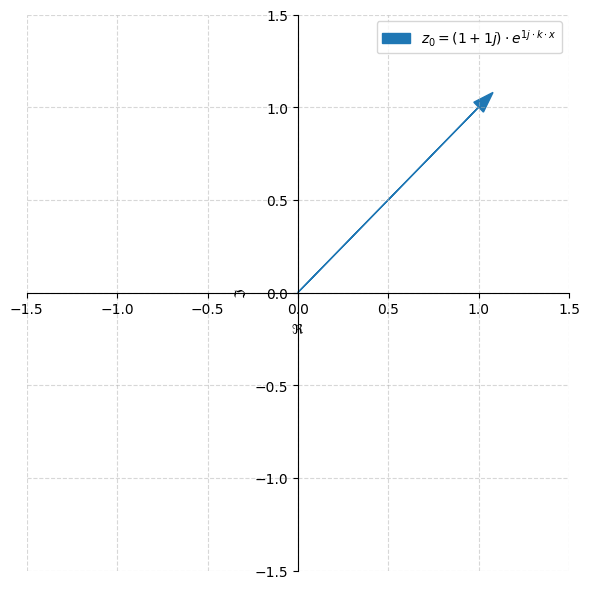

In [14]:
c_k = 1 + 1j

z = calc_four(c_k, 0)
x = np.real(z)
y = np.imag(z)

fig, ax = plt.subplots(figsize=(6, 6))

# Achsenlinien zeichnen
set_axes_cross(ax)

# Achsenskalierung gleichmäßig halten
size = 1.5
ax.set_xlim(-size, size)
ax.set_ylim(-size, size)

ax.arrow(0, 0, 
         x, y, 
         head_width=size * 0.05,
         color= '#1f77b4',
         label=fr'$z_0 = {c_k} \cdot e^{{{1j} \cdot k \cdot x}}$'
         )

# Winkel anzeigen
angle = np.angle(z)

ax.set_xlabel(r'$\Re$')
ax.set_ylabel(r'$\Im$')


plt.legend()
plt.tight_layout()
plt.show()


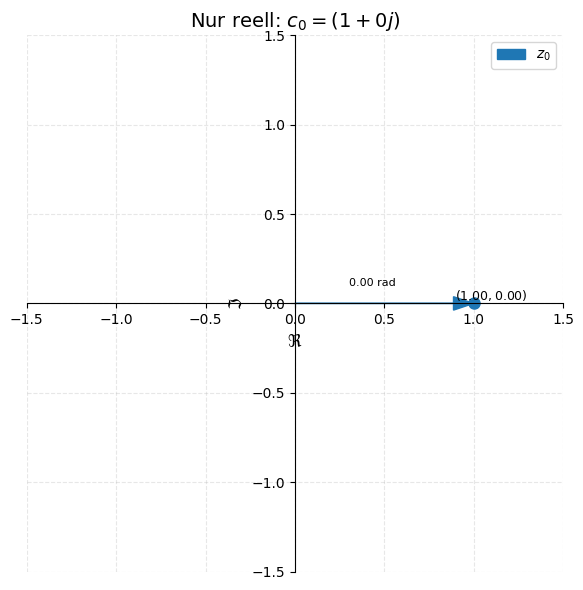

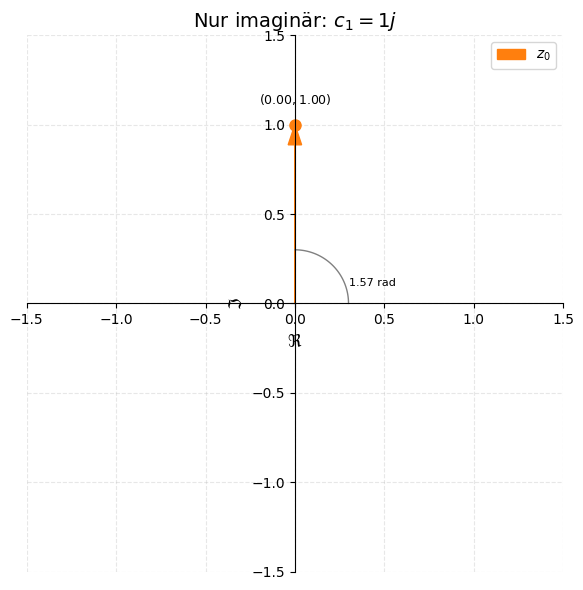

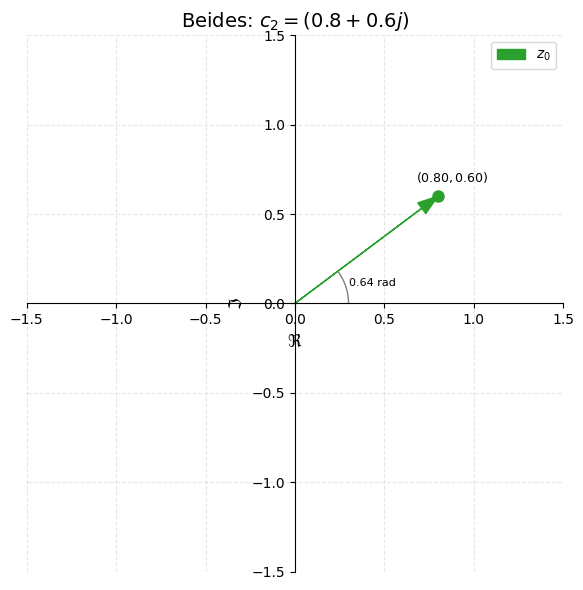

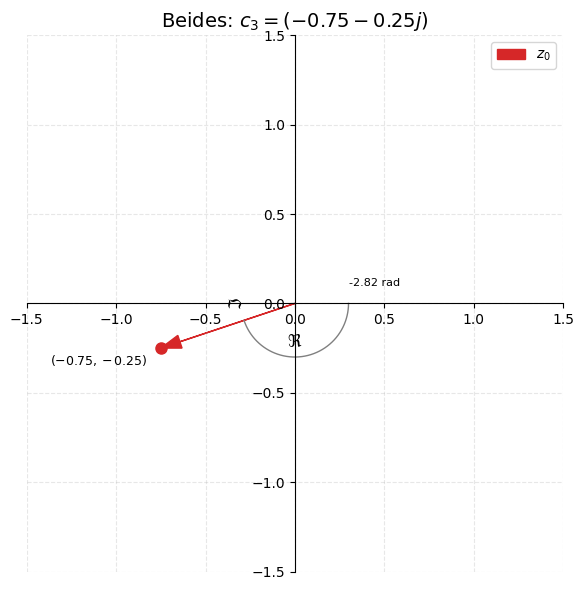

In [15]:
#  Verschiedene komplexe Startwerte c_k und Parameter k
plots_data = [
    {'c_k': 1 + 0j, 'k': 0, 'color': '#1f77b4', 'title': 'Nur reell'},
    {'c_k': 0 + 1j, 'k': 1, 'color': '#ff7f0e', 'title': 'Nur imaginär'},
    {'c_k': 0.8 + 0.6j, 'k': 2, 'color': '#2ca02c', 'title': 'Beides'},
    {'c_k': -0.75 - 0.25j, 'k': 3, 'color': '#d62728', 'title': 'Beides'}
]

for i, data in enumerate(plots_data):
    # Berechnung von z (hier vereinfacht als Beispiel)
    # Annahme: calc_four berechnet z = c_k * e^(i*k*x) mit x=0 → z = c_k
    c_k = data['c_k']
    k = data['k']
    x_param = 0  # wie im Originalcode
    
    # Einfache Berechnung: z = c_k wenn x=0
    z = c_k * np.exp(1j * k * x_param)
    
    x = np.real(z)
    y = np.imag(z)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Achsenlinien zeichnen
    set_axes_cross(ax)
    
    # Achsenskalierung gleichmäßig halten
    size = 1.5
    ax.set_xlim(-size, size)
    ax.set_ylim(-size, size)
    ax.set_aspect('equal')
    
    # Pfeil vom Ursprung zum Punkt zeichnen
    ax.arrow(0, 0, 
             x, y, 
             head_width=size * 0.05,
             length_includes_head=True,
             color=data['color'],
             label=r'$z_0$'
             )
    
    # Punkt markieren
    ax.plot(x, y, 'o', color=data['color'], markersize=8)
    
    # Koordinaten beschriften
    ax.text(x*1.1, y*1.1, fr'$({x:.2f}, {y:.2f})$', 
            fontsize=9, ha='center' if x >= 0 else 'right',
            va='bottom' if y >= 0 else 'top')
    
    # Winkel anzeigen
    angle = np.angle(z)
    arc_radius = 0.3
    theta = np.linspace(0, angle, 50)
    ax.plot(arc_radius*np.cos(theta), arc_radius*np.sin(theta), 
            color='gray', linewidth=1)
    ax.annotate(f'{angle:.2f} rad', xy=(arc_radius/1, 0.1), fontsize=8)
    
    # Labels und Legende
    ax.set_xlabel(r'$\Re$', fontsize=12)
    ax.set_ylabel(r'$\Im$', fontsize=12)
    ax.set_title(f"{data['title']}: $c_{k} = {data['c_k']}$", fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
#     plt.savefig(f'complex_plot_{i+1}.pdf', dpi=300)
    plt.show()

1.0 0.0
0.0 1.0
0.8 0.6
-0.75 -0.25


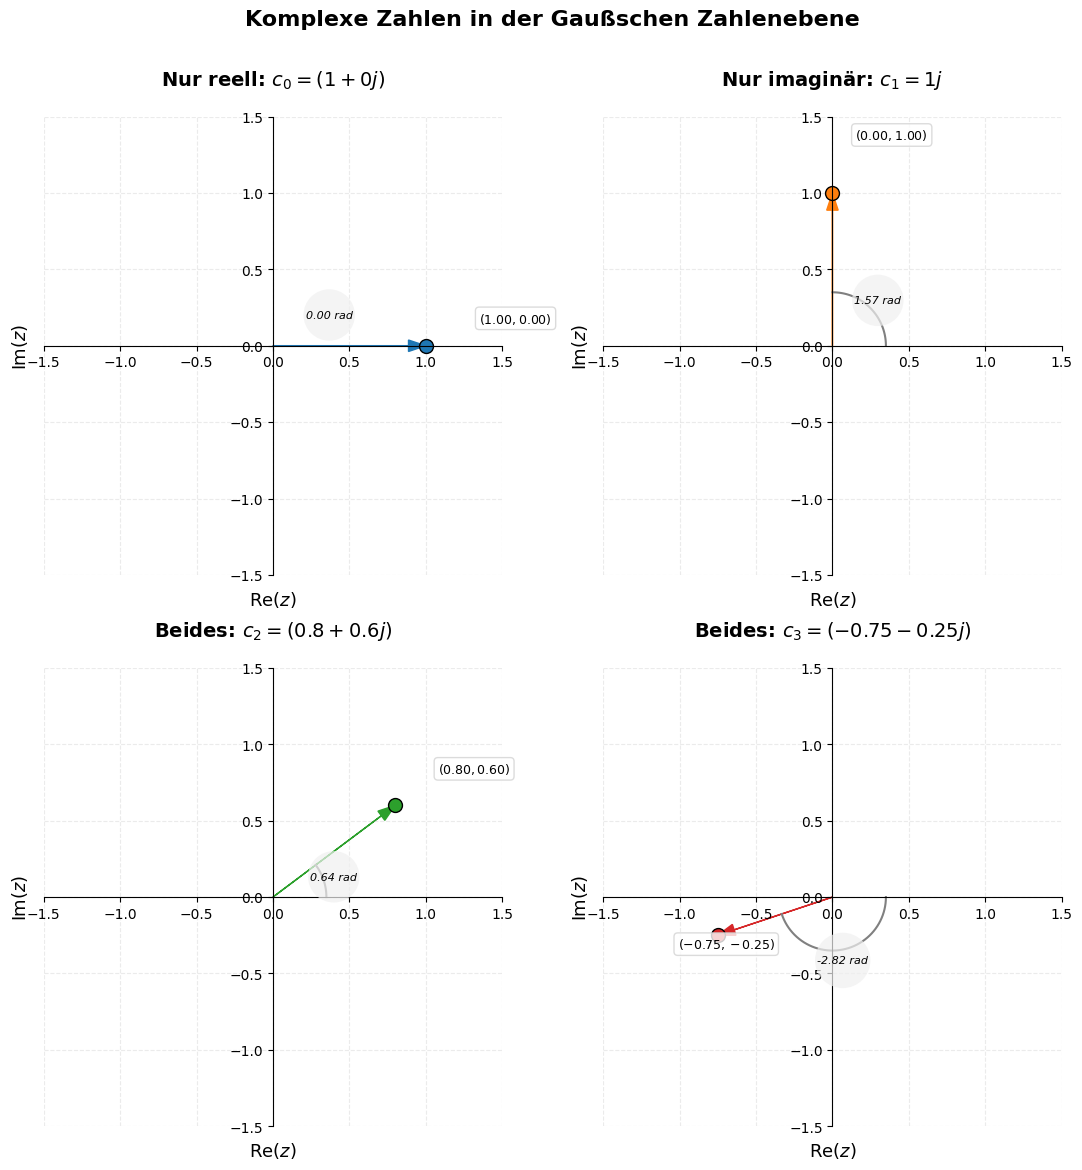

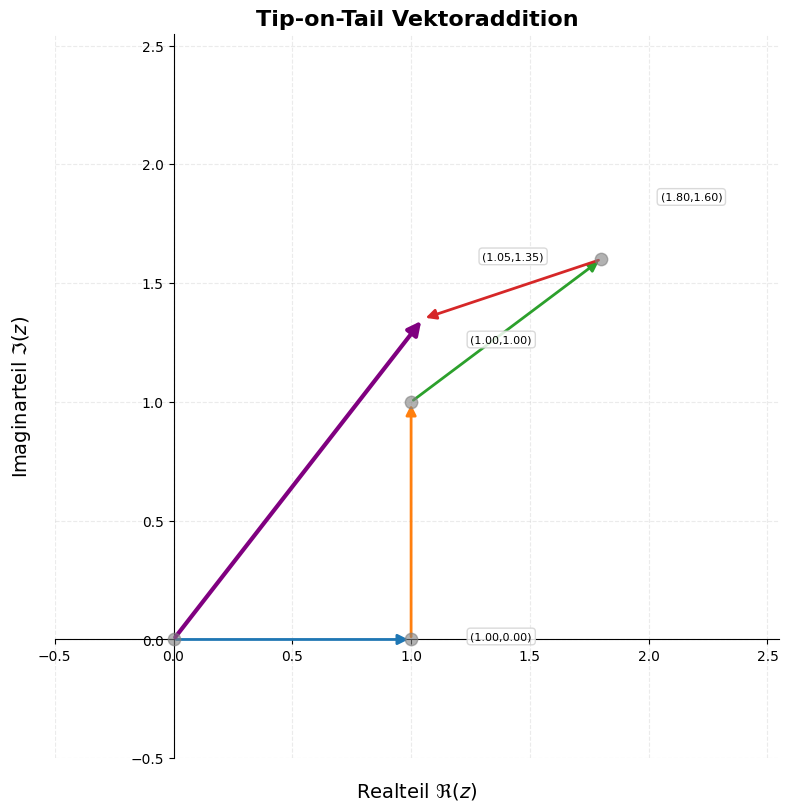

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def set_axes_cross(ax):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

plots_data = [
    {'c_k': 1 + 0j, 'k': 0, 'color': '#1f77b4', 'title': 'Nur reell'},
    {'c_k': 0 + 1j, 'k': 1, 'color': '#ff7f0e', 'title': 'Nur imaginär'},
    {'c_k': 0.8 + 0.6j, 'k': 2, 'color': '#2ca02c', 'title': 'Beides'},
    {'c_k': -0.75 - 0.25j, 'k': 3, 'color': '#d62728', 'title': 'Beides'}
]

# VERBESSERUNGEN: Größerer Figurenabstand, mehr Platz für Labels
fig, axes = plt.subplots(2, 2, figsize=(11, 11), constrained_layout=True)
axes = axes.flatten()

size = 1.5

for i, data in enumerate(plots_data):
    ax = axes[i]
    
    c_k = data['c_k']
    k = data['k']
    x_param = 0
    
    z = c_k * np.exp(1j * k * x_param)
    x = np.real(z)
    y = np.imag(z)
    print(x,y)
    
    set_axes_cross(ax)
    ax.set_xlim(-size, size)
    ax.set_ylim(-size, size)
    ax.set_aspect('equal')
    
    # Vektor zeichnen
    ax.arrow(0, 0, x, y, 
             head_width=size * 0.05,
             length_includes_head=True,
             color=data['color'],
             label=r'$z_0$')
    
    # Punkt markieren
    ax.plot(x, y, 'o', color=data['color'], markersize=10, 
            markeredgecolor='black', markeredgewidth=1)
    
    offset_factor = 1.3  # Mehr Abstand zum Punkt
    pad_x = abs(x) * 0.05 if x != 0 else 0.15
    pad_y = abs(y) * 0.05 if y != 0 else 0.15
    
    coord_label_pos_x = np.sign(x) * (abs(x) * offset_factor + pad_x) if x != 0 else pad_x
    coord_label_pos_y = np.sign(y) * (abs(y) * offset_factor + pad_y) if y != 0 else pad_y
    
    ax.text(coord_label_pos_x, coord_label_pos_y, 
            fr'$({x:.2f}, {y:.2f})$', 
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='lightgray', alpha=0.8, linewidth=1))
    
    # Winkel-Arc mit besserer Positionierung
    angle = np.angle(z)
    arc_radius = 0.35
    theta = np.linspace(0, angle, 50)
    ax.plot(arc_radius*np.cos(theta), arc_radius*np.sin(theta), 
            color='gray', linewidth=1.5)
    
    # Winkel-Text weiter vom Zentrum platziert
    angle_text_r = arc_radius * 1.2
    angle_text_theta = angle / 2 if angle != 0 else 0.5
    ax.text(angle_text_r * np.cos(angle_text_theta), 
            angle_text_r * np.sin(angle_text_theta),
            f'{angle:.2f} rad', fontsize=8, fontstyle='italic',
            ha='center', va='center',
            bbox=dict(boxstyle='circle,pad=0.2', facecolor='#f0f0f0', 
                     edgecolor='none', alpha=0.7))
    
    # AXSEN-BESCHRIFTUNGEN WEITER WEG VOM URSPRUNG
    # Vermeidet Überlappung mit dem Ursprungspunkt und Koordinaten-Labels
    ax.set_xlabel(r'$\text{Re}(z)$', fontsize=13, fontweight='bold')
    ax.set_ylabel(r'$\text{Im}(z)$', fontsize=13, fontweight='bold')
    
    # Positionsparameter verschieben Achsentitel nach unten/rechts
    ax.xaxis.set_label_coords(0.5, -0.03)  # Weiter unten
    ax.yaxis.set_label_coords(-0.03, 0.5)   # Weiter links
    
    # Gitternetz mit geringerer Opazität für bessere Lesbarkeit
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
    ax.set_title(f"{data['title']}: $c_{k} = {data['c_k']}$", 
                 fontsize=14, fontweight='bold', y=1.05)
    
    # Legende entfernen da nur ein Vektor pro Plot
    # ax.get_legend().remove()

plt.suptitle('Komplexe Zahlen in der Gaußschen Zahlenebene', 
             fontsize=16, fontweight='bold', y=1.05)
plt.savefig(f'{savefolder}complex_subplots_improved_xSetTo{x_param}.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# TIP-ON-TAIL ADDITION MIT BESSEREN ACHSEN
# ============================================
fig2, ax2 = plt.subplots(figsize=(8, 8), constrained_layout=True)
set_axes_cross(ax2)

all_vectors = [(np.real(d['c_k']), np.imag(d['c_k'])) for d in plots_data]
total_x = sum(v[0] for v in all_vectors)
total_y = sum(v[1] for v in all_vectors)

max_coord = max(abs(total_x), abs(total_y)) + 1.2  # Extra Padding
ax2.set_xlim(-0.5, max_coord)
ax2.set_ylim(-0.5, max_coord)
ax2.set_aspect('equal')

current_x, current_y = 0, 0
points_x = [current_x]
points_y = [current_y]
point_labels = ['Origin']

for idx, (dx, dy) in enumerate(all_vectors):
    next_x = current_x + dx
    next_y = current_y + dy
    
    arrow_style = '-|>'
    ax2.annotate('', xy=(next_x, next_y), xytext=(current_x, current_y),
                arrowprops=dict(arrowstyle=arrow_style, 
                               color=plots_data[idx]['color'], 
                               lw=2,
                               mutation_scale=15))
    
    points_x.append(next_x)
    points_y.append(next_y)
    point_labels.append(f'P{idx+1}')
    
    current_x, current_y = next_x, next_y

# Weg-Linie als gestrichelt

# ax2.plot(points_x, points_y, 'k--', alpha=0.4, linewidth=1.2, label='Weg')

# # Endpunkt groß markieren
# ax2.scatter(points_x[-1], points_y[-1], s=200, c='purple', 
#            marker='*', edgecolors='darkred', linewidths=1.5, 
#            zorder=10, label=r'$\sum \vec{v}_i$')

# Alle Punkte kleiner markieren
ax2.scatter(points_x[:-1], points_y[:-1], s=80, c='gray', 
           marker='o', alpha=0.6, zorder=5)

# Koordinatentexte an Punkten (mit Whitebox vor Overlapping)
for px, py, plabel in zip(points_x, points_y, point_labels):
    if plabel == 'Origin':
        continue
    offset_sign_x = 1 if px > 0 else (-1 if px < 0 else 0)
    offset_sign_y = 1 if py > 0 else (-1 if py < 0 else 0)
    
    text_offset = 0.25
    ax2.text(px + offset_sign_x * text_offset, 
             py + offset_sign_y * text_offset,
             f'({px:.2f},{py:.2f})', fontsize=8,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                      edgecolor='lightgray', alpha=0.85))

# Resultierender Vektor vom Ursprung
resultant_len = np.sqrt(total_x**2 + total_y**2)
if resultant_len > 0.1:
    ax2.annotate('', xy=(total_x, total_y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color='purple', 
                               lw=3, mutation_scale=20))
    # Beschriftung für Resultante
    # ax2.text(total_x*1.1, total_y*1.1, r'$\mathbf{\Sigma v_i}$', 
    #          fontsize=12, fontweight='bold', color='purple',
    #          bbox=dict(boxstyle='round,pad=0.4', facecolor='plum', 
    #                   edgecolor='purple', alpha=0.8))

# Verbesserte Achsenbeschriftung
ax2.set_xlabel(r'$\text{Realteil } \Re(z)$', fontsize=14, fontweight='bold')
ax2.set_ylabel(r'$\text{Imaginarteil } \Im(z)$', fontsize=14, fontweight='bold')
ax2.xaxis.set_label_coords(0.5, -0.03)
ax2.yaxis.set_label_coords(-0.03, 0.5)

ax2.set_title(r'Tip-on-Tail Vektoraddition', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
# ax2.legend(loc='best', fontsize=10)

plt.savefig(f'{savefolder}vector_addition_tip_on_tail_improved_xSetTo{x_param}.pdf', dpi=300, bbox_inches='tight')
plt.show()

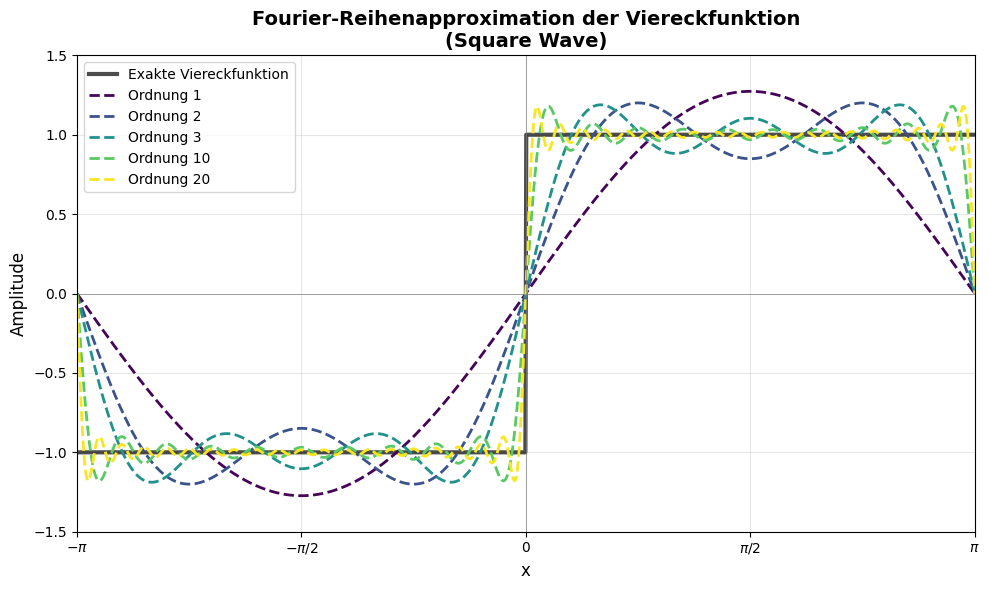

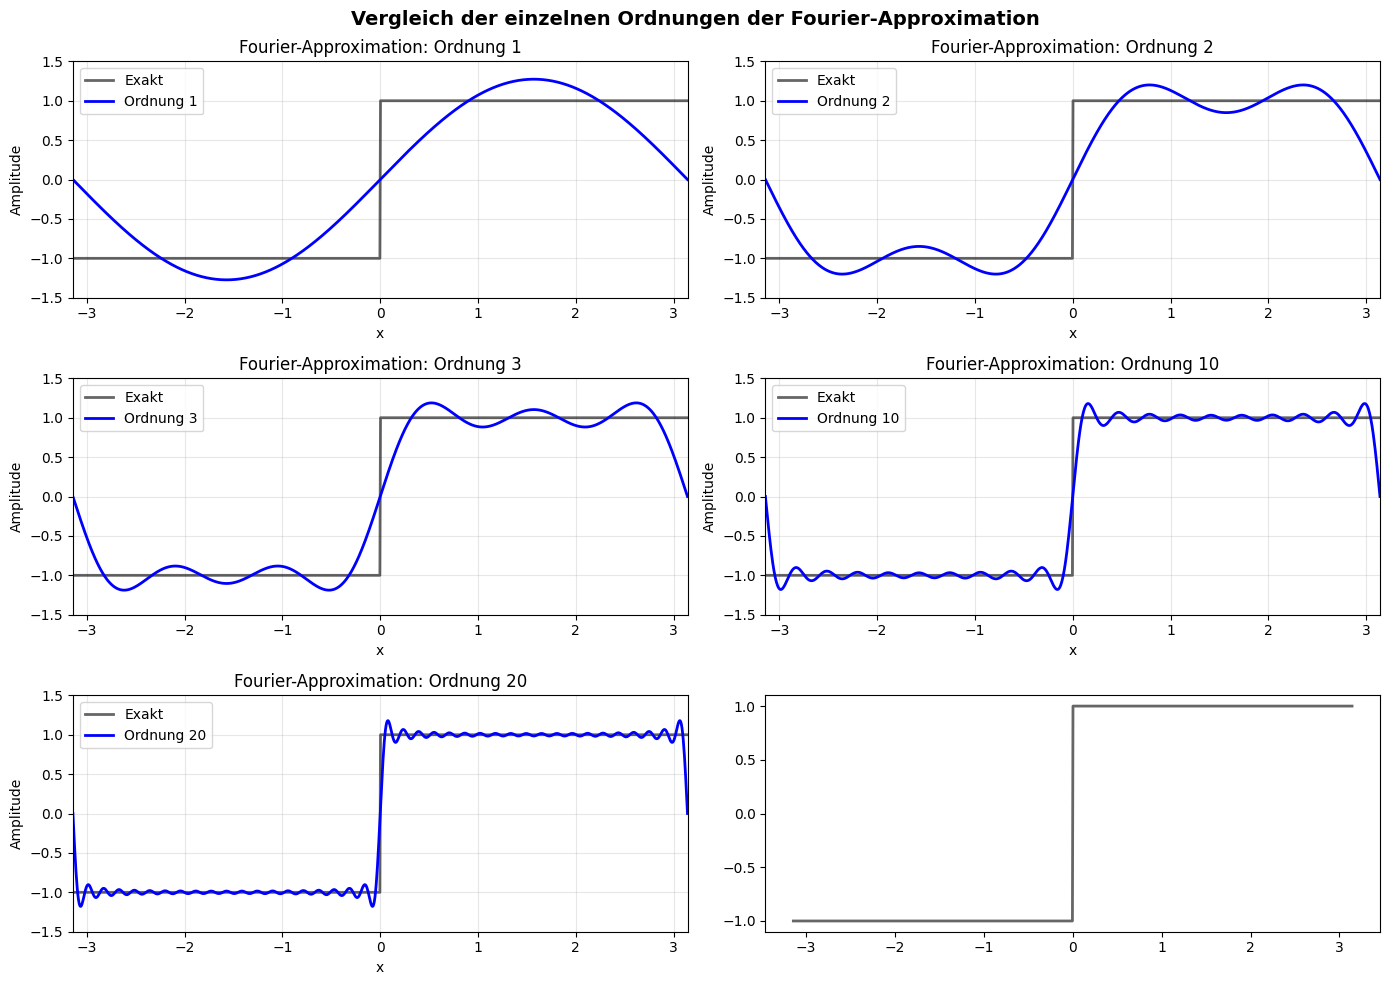

In [ ]:
def fourier_square_wave(x, n_terms):
    """
    Berechnet die Fourier-Reihenapproximation einer Viereckfunktion
    mit n_terms Termen (nur ungerade Harmonische werden verwendet).
    
    Parameters:
    x: numpy array der x-Werte
    n_terms: Anzahl der Terme in der Fourierreihe
    
    Returns:
    Approximierte Funktionswerte
    """
    result = np.zeros_like(x)
    for k in range(1, n_terms + 1):
        n = 2*k - 1  # Nur ungerade Harmonische (1, 3, 5, ...)
        result += (np.sin(n * x) / n)
    
    return (4/np.pi) * result

def exact_square_wave(x):
    """
    Erzeugt die exakte Viereckfunktion im Bereich [-π, π]
    """
    return np.sign(np.sin(x))

# x-Achse definieren (ein voller Zyklus von -π bis π)
x = np.linspace(-np.pi, np.pi, 1000)

# Exakte Viereckfunktion berechnen
y_exact = exact_square_wave(x)

# Verschiedene Ordnungen der Fourier-Approximation berechnen
orders = [1, 2, 3, 10, 20, 100]

# Plot erstellen
plt.figure(figsize=(10, 6))
plt.plot(x, y_exact, 'k-', linewidth=3, label='Exakte Viereckfunktion', alpha=0.7)

colors = plt.cm.viridis(np.linspace(0.01, 0.99, len(orders)))

for i, order in enumerate(orders):
    y_approx = fourier_square_wave(x, order)
    plt.plot(x, y_approx, color=colors[i], linewidth=2, 
             label=f'Ordnung {order}', linestyle='--')

# Achsen beschriften
plt.xlabel('x', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Fourier-Reihenapproximation der Viereckfunktion\n(Square Wave)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([-np.pi, np.pi])
plt.ylim([-1.5, 1.5])
plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           [r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

# Gibbs-Phänomen markieren
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{savefolder}Fourier_Viereck_Überlagerung.pdf')
plt.show()

# Optional: Einzelne Plots für jede Ordnung
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

# Exakten Plot auf allen Positionen als Referenz zeigen
for ax in axes:
    ax.plot(x, y_exact, 'k-', linewidth=2, label='Exakt', alpha=0.6)

# Ordungen zuordnen
plot_orders = [(1, 0), (2, 1), (3, 2), (10, 3), (20, 4)]

for order, ax_idx in plot_orders:
    y_approx = fourier_square_wave(x, order)
    axes[ax_idx].plot(x, y_approx, 'b-', linewidth=2, label=f'Ordnung {order}')
    axes[ax_idx].set_title(f'Fourier-Approximation: Ordnung {order}', fontsize=12)
    axes[ax_idx].set_xlabel('x')
    axes[ax_idx].set_ylabel('Amplitude')
    axes[ax_idx].set_xlim([-np.pi, np.pi])
    axes[ax_idx].set_ylim([-1.5, 1.5])
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)

# axes[5].axis()  # Letzten leeren Subplot deaktivieren

plt.suptitle('Vergleich der einzelnen Ordnungen der Fourier-Approximation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{savefolder}Fourier_Viereck_Einzeln.pdf')
plt.show()

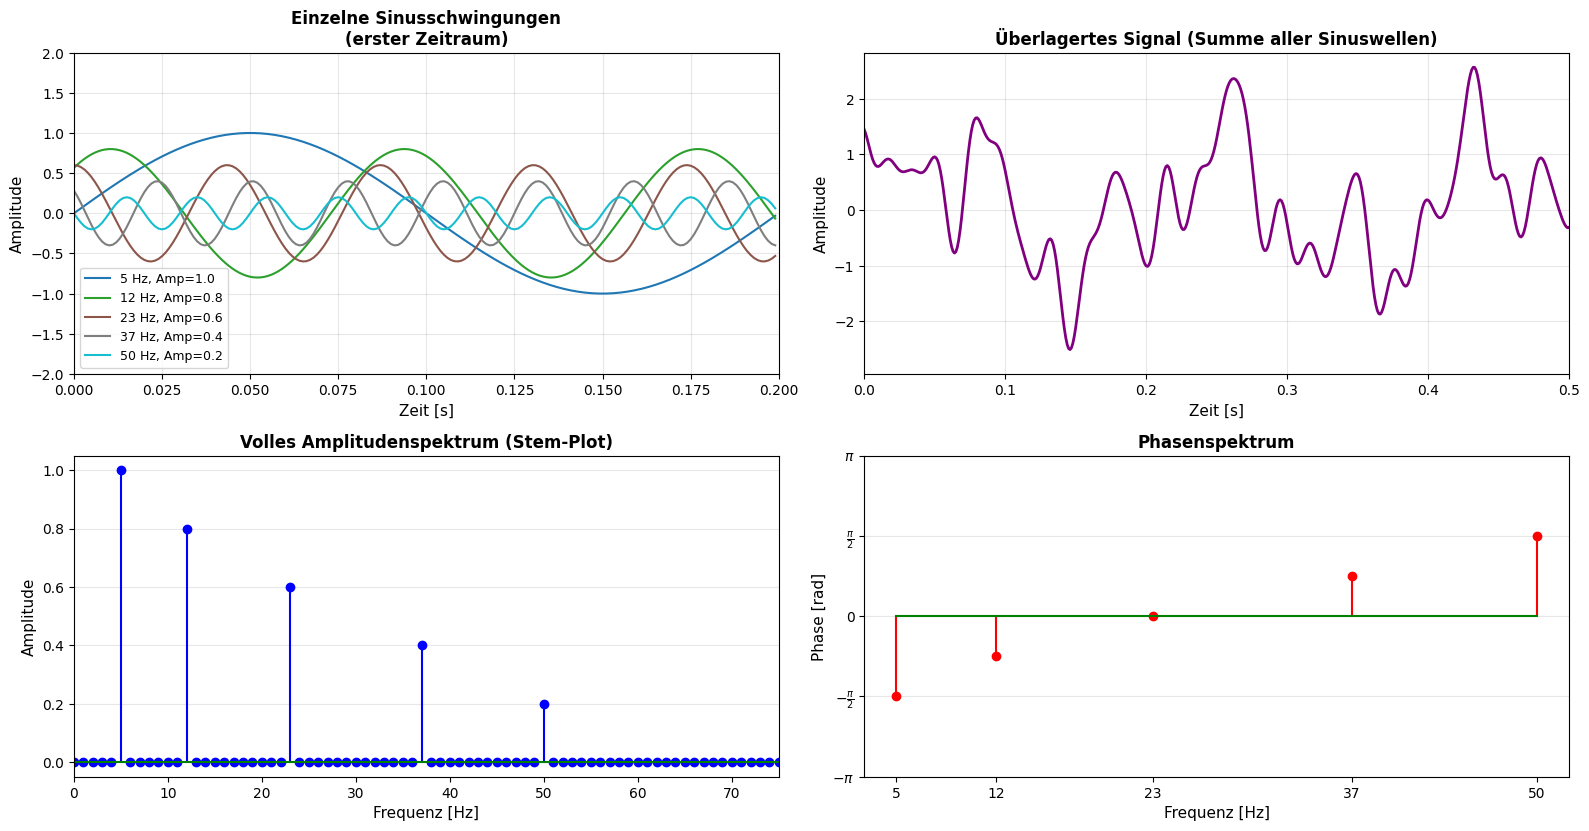

In [34]:
# ============================================
# Parameter definieren
# ============================================

# Sampling-Parameter
sampling_rate = 1000  # Samples pro Sekunde
duration = 1.0  # Sekunden
n_samples = int(sampling_rate * duration)
t = np.linspace(0, duration, n_samples, endpoint=False)

# Frequenzen der Sinusschwingungen (in Hz)
frequencies = [5, 12, 23, 37, 50]  # Beispiel-Frequenzen
amplitudes = [1.0, 0.8, 0.6, 0.4, 0.2]  # Correspondende Amplituden
phases = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]  # Phasenverschiebungen

# ============================================
# Signale erzeugen
# ============================================

# Einzelne Sinus-Signale
sine_signals = []
for f, amp, phase in zip(frequencies, amplitudes, phases):
    signal = amp * np.sin(2 * np.pi * f * t + phase)
    sine_signals.append(signal)

# Überlagertes Gesamtsignal (Superposition)
signal_sum = sum(sine_signals)

# ============================================
# Fourier-Transformation berechnen
# ============================================

# FFT berechnen
fft_result = fft(signal_sum)
fft_freq = fftfreq(n_samples, 1/sampling_rate)

# Nur positive Frequenzen betrachten
positive_mask = fft_freq >= 0
fft_freq_pos = fft_freq[positive_mask]
fft_magnitude = np.abs(fft_result[positive_mask]) / n_samples * 2  # Normalisierung
fft_phase = np.angle(fft_result[positive_mask])

# ============================================
# Plotting
# ============================================

fig = plt.figure(figsize=(16, 12))

# --- Plot 1: Einzelne Sinusschwingungen ---
ax1 = fig.add_subplot(3, 2, 1)
colors = plt.cm.tab10(np.linspace(0, 1, len(frequencies)))

for i, (freq, signal, color) in enumerate(zip(frequencies, sine_signals, colors)):
    plt.plot(t[:200], signal[:200], color=color, linewidth=1.5, 
             label=f'{freq} Hz, Amp={amplitudes[i]}')  # Nur ersten Teil anzeigen

plt.xlabel('Zeit [s]', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.title('Einzelne Sinusschwingungen\n(erster Zeitraum)', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim([0, 0.2])
plt.ylim([-2, 2])

# --- Plot 2: Überlagertes Signal ---
ax2 = fig.add_subplot(3, 2, 2)
plt.plot(t, signal_sum, 'purple', linewidth=2)
plt.xlabel('Zeit [s]', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.title('Überlagertes Signal (Summe aller Sinuswellen)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim([0, 0.5])  # Erste Hälfte für bessere Übersicht

# # --- Plot 3: Zeitbereich - Alle Signale übereinander ---
# ax3 = fig.add_subplot(3, 2, 3)
# for i, (freq, signal, color) in enumerate(zip(frequencies, sine_signals, colors)):
#     plt.plot(t[:300], signal[:300], color=color, linewidth=1, alpha=0.7,
#              label=f'{freq} Hz')

# plt.plot(t[:300], signal_sum[:300], 'black', linewidth=2, label='Summe')
# plt.xlabel('Zeit [s]', fontsize=11)
# plt.ylabel('Amplitude', fontsize=11)
# plt.title('Zeitbereich: Vergleich Einzelsignale vs. Summe', fontsize=12, fontweight='bold')
# plt.legend(fontsize=9)
# plt.grid(True, alpha=0.3)
# plt.xlim([0, 0.3])
# plt.ylim([-2.5, 2.5])

# # --- Plot 4: Amplitudenspektrum (Magnitude) ---
# ax4 = fig.add_subplot(3, 2, 4)
# bar_width = 0.4
# plt.bar(fft_freq_pos[frequencies], fft_magnitude[frequencies], 
#         width=bar_width, color=colors, alpha=0.7, edgecolor='black')

# # Referenz-Linien für theoretische Amplituden
# for freq, amp, color in zip(frequencies, amplitudes, colors):
#     plt.axhline(y=amp, color=color, linestyle='--', alpha=0.5, linewidth=1)

# plt.xlabel('Frequenz [Hz]', fontsize=11)
# plt.ylabel('Amplitude', fontsize=11)
# plt.title('Frequenzspektrum (Fourier-Amplituden)', fontsize=12, fontweight='bold')
# plt.xticks(frequencies)
# plt.grid(True, alpha=0.3, axis='y')

# --- Plot 5: Vollständiges Frequenzspektrum ---
ax5 = fig.add_subplot(3, 2, 3)
# Nur relevante Frequenzbereiche zeigen
max_freq_show = max(frequencies) * 1.5
mask = fft_freq_pos <= max_freq_show
plt.stem(fft_freq_pos[mask], fft_magnitude[mask], linefmt='b-', 
         markerfmt='bo', basefmt='g-')
plt.xlabel('Frequenz [Hz]', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.title('Volles Amplitudenspektrum (Stem-Plot)', fontsize=12, fontweight='bold')
plt.xlim([0, max_freq_show])
plt.grid(True, alpha=0.3, axis='y')

# --- Plot 6: Phasenspektrum ---
ax6 = fig.add_subplot(3, 2, 4)
plt.stem(fft_freq_pos[frequencies], fft_phase[frequencies], 
         linefmt='r-', markerfmt='ro', basefmt='g-')
plt.xlabel('Frequenz [Hz]', fontsize=11)
plt.ylabel('Phase [rad]', fontsize=11)
plt.title('Phasenspektrum', fontsize=12, fontweight='bold')
plt.xticks(frequencies)
plt.yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
           [r'$-\pi$', r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$', r'$\pi$'])
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{savefolder}fourier_spectrum_analysis.pdf', dpi=150, bbox_inches='tight')
plt.show()